In [12]:
import numpy as np 
import matplotlib.pyplot as plt


def conic(a, e, w =0, single = False,p=None , nu=0, resol=540, nu_min=0, nu_max=2*np.pi):
    theta = np.nan
    nu_inf = np.acos(-1/e) if e > 1 else None
    if single:
        if e > 1 and abs(nu) > nu_inf:
            print(f"BEYOND ORBIT ASYMPTOTE : {np.rad2deg(nu_inf)}")
            return [np.nan, np.nan]
        theta = nu
    else:
        if e > 1:
            nu_min = -nu_inf + 0.001
            nu_max = nu_inf - 0.001
        theta = np.linspace(nu_min, nu_max, resol)
    # Determine p (semi-latus rectum)
    if p is None:
        if e == 1:
            raise ValueError("For parabola (e=1), you must provide p explicitly (a is infinite)")
        p = a * (1 - e**2)
    r = p / (1 + e * np.cos(theta))
    r = r * np.array([np.cos(theta + w), 
                      np.sin(theta + w)
                    ])
    return r

def obt_vel(mu,a, e, w = 0,single=False, p=None,nu=0, resol=540, nu_min=0, nu_max=2*np.pi):
    nu_inf = np.acos(-1/e) if e > 1 else None
    if single:
        if e > 1 and abs(nu) > nu_inf:
            print(f"BEYOND ORBIT ASYMPTOTE : {np.rad2deg(nu_inf)}")
            return [np.nan, np.nan]
        theta = nu
    else:
        if e > 1:
            nu_min = -nu_inf + 0.001
            nu_max = nu_inf - 0.001
        theta = np.linspace(nu_min, nu_max, resol)

    # Determine p (semi-latus rectum)
    if p is None:
        if a is None:
            raise ValueError("Either p or a must be provided")
        if e == 1:
            raise ValueError("For parabola (e=1), you must provide p explicitly (a is infinite)")
        p = a * (1 - e**2)
    # Velocity vector using simplified form
    v = np.sqrt(mu / p) * np.array([
        -np.sin(theta + w) - e * np.sin(w),
         np.cos(theta + w) + e * np.cos(w)
    ])
    
    return v

Intersection possible
nu    = 2.87822	 nu deg = 164.90981
dvmag = 0.34492


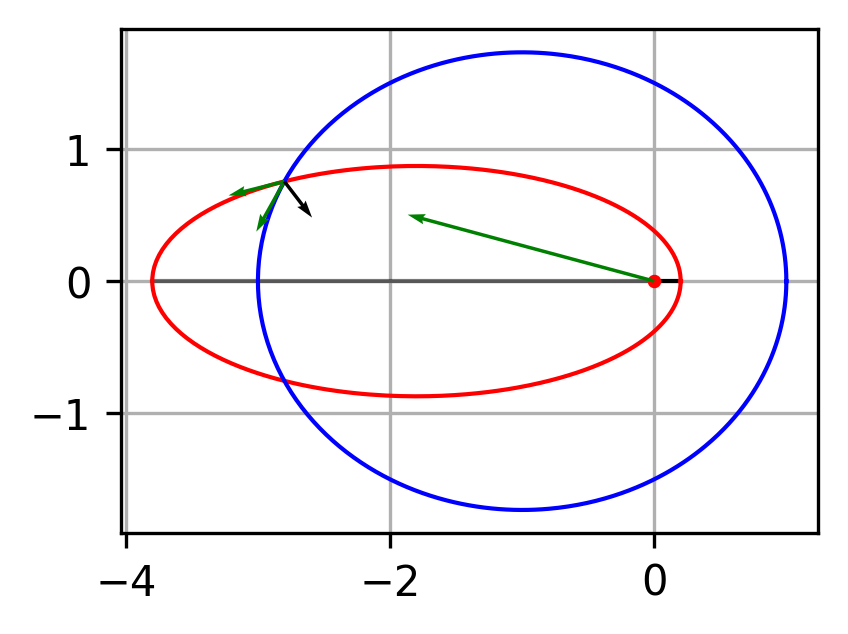

In [13]:
## CHANFE PE AND AP
mu = 1
a1 = 2
e1 = 0.9
w1 = 0
nu = np.deg2rad(30) 
p1 = a1 * (1 - e1**2)
obt1 = conic(a1,e1,w1)
periapsis_og =   a1 * (1-e1) * np.array([np.cos(w1),np.sin(w1)])
apoapsis_og  = - a1 * (1+e1) * np.array([np.cos(w1),np.sin(w1)])

plt.figure(figsize=(3,3),dpi=300)
plt.plot([0,apoapsis_og [0]],[0,apoapsis_og [1]],'k-',lw=1,alpha = 0.5)
plt.plot([0,periapsis_og[0]],[0,periapsis_og[1]],'k-',lw=1)
plt.plot(obt1[0],obt1[1],'r-',lw=1)
plt.scatter(0,0,color='r',s=5,zorder = 5)
plt.gca().set_aspect("equal")
plt.grid()


pe2 = 1
ap2 = 3
a2  = (pe2 + ap2) / 2
e2  = (ap2 - pe2) / (ap2 + pe2)
p2 = a2 * (1 - e2**2)
w2 = w1
obt2 = conic(a2,e2,w2)
plt.plot(obt2[0],obt2[1],'b-',lw=1)

second_half = False
if (p1 * e2 - p2 * e1) == 0:
    print( "Same orbit")
else:
    cos_nu = (p2 - p1) / (p1 * e2 - p2 * e1)
if abs(cos_nu) > 1:
    print("Orbit not possible")
elif abs(cos_nu) == 1:
    print("Single intersection point")
elif abs(cos_nu) < 1:
    print("Intersection possible")
    nu = np.acos(cos_nu)
    if second_half:
        nu = 2*np.pi - nu
    pos = conic(a1,e1,w1,single=True,nu=nu)
    plt.quiver(0,0,pos[0],pos[1], angles='xy', scale_units='xy', scale = 1.5, color = 'green',zorder = 5,width=0.005)
    print(f"nu    = {nu:.5f}\t nu deg = {np.rad2deg(nu):.5f}")
    v1 = obt_vel(mu,a1,e1,w1,single=True,nu=nu)
    v2 = obt_vel(mu,a2,e2,w2,single=True,nu=nu)
    
    dV = v2 - v1
    print(f"dvmag = {np.linalg.norm(dV):.5f}")
    plt.quiver(pos[0], pos[1], v1[0], v1[1],
            angles='xy', scale_units='xy', scale=1, color='green', zorder=5,width=0.005)

    plt.quiver(pos[0], pos[1], v2[0], v2[1],
            angles='xy', scale_units='xy', scale=1, color='green', zorder=5,width=0.005)
    plt.quiver(pos[0], pos[1], dV[0], dV[1],
            angles='xy', scale_units='xy', scale=1, color='black', zorder=5,width=0.005)
plt.show()



nu1 = 22.50000	 nu2 = 202.50000
dv1 = 0.25512	 v2  = 0.25512


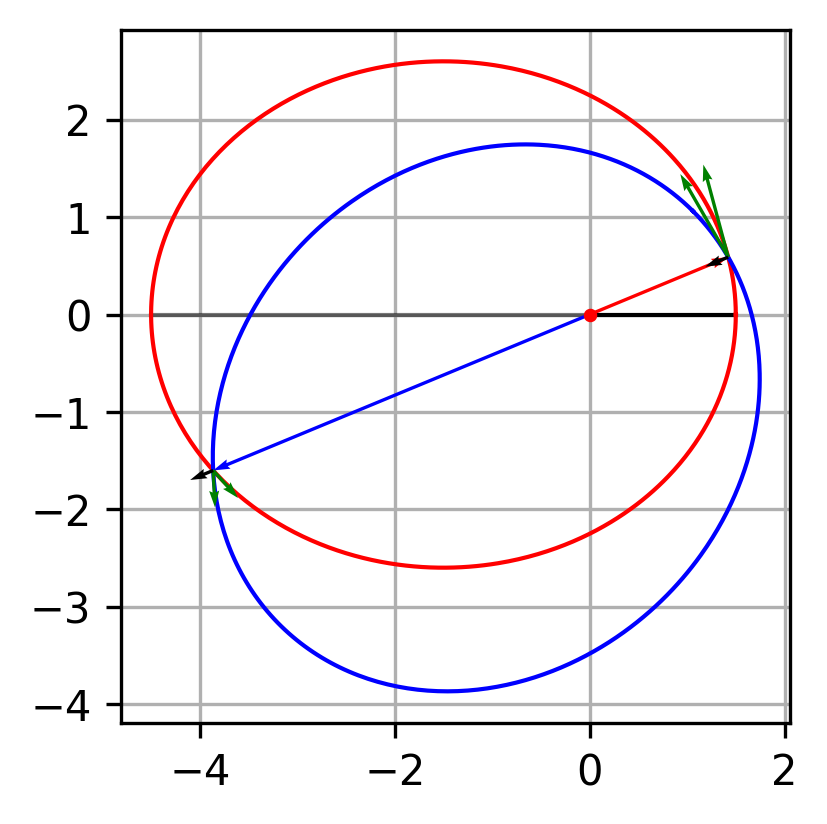

In [14]:
## change arg peri
a1 = 3
e1 = 0.5
w1 = np.deg2rad(0)
nu = np.deg2rad(30) 


obt1 = conic(a1,e1,w1)
periapsis_og =   a1 * (1-e1) * np.array([np.cos(w1),np.sin(w1)])
apoapsis_og  = - a1 * (1+e1) * np.array([np.cos(w1),np.sin(w1)])
plt.figure(figsize=(3,3),dpi=300)
plt.plot([0,apoapsis_og [0]],[0,apoapsis_og [1]],'k-',lw=1,alpha = 0.5)
plt.plot([0,periapsis_og[0]],[0,periapsis_og[1]],'k-',lw=1)
plt.plot(obt1[0],obt1[1],'r-',lw=1)
plt.scatter(0,0,color='r',s=5,zorder = 5)
plt.gca().set_aspect("equal")
plt.grid()


w2 = np.deg2rad(45)
delta_w = w2 - w1
obt2 = conic(a1,e1,w2)
plt.plot(obt2[0],obt2[1],'b-',lw=1)
if w1 < 0:
    print("NEGATIVE ARGPERI VALUE")
if w2 < 0:
    print("NEGATIVE ARGPERI VALUE")

nu1 = delta_w / 2
if nu1 < 0:
    nu1 += np.pi
nu2 = nu1 + np.pi

print(f"nu1 = {np.rad2deg(nu1):.5f}\t nu2 = {np.rad2deg(nu2):.5f}")

pos1 = conic(a1,e1,w1,single=True,nu=nu1)
pos2 = conic(a1,e1,w1,single=True,nu=nu2)

v11 = obt_vel(mu,a1,e1,w1,single=True,nu=nu1) 
v21 = obt_vel(mu,a1,e1,w2,single=True,nu=(nu1 - delta_w))
dV1 = v21 - v11 
v12 = obt_vel(mu,a1,e1,w1,single=True,nu=nu2) 
v22 = obt_vel(mu,a1,e1,w2,single=True,nu=(nu2 - delta_w))
dV2 = v22 - v12 
print(f"dv1 = {np.linalg.norm(dV1):.5f}\t v2  = {np.linalg.norm(dV2):.5f}")
plt.quiver(0,0,pos1[0],pos1[1],color='red',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
plt.quiver(0,0,pos2[0],pos2[1],color='blue' ,scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
plt.quiver(pos1[0],pos1[1],v11[0],v11[1],color='green',scale = 1,zorder = 3,angles='xy', scale_units='xy',width=0.005)
plt.quiver(pos1[0],pos1[1],v21[0],v21[1],color='green',scale = 1,zorder = 3,angles='xy', scale_units='xy',width=0.005)
plt.quiver(pos1[0],pos1[1],dV1[0],dV1[1],color='black',scale = 1,zorder = 4,angles='xy', scale_units='xy',width=0.005)
plt.quiver(pos2[0],pos2[1],v12[0],v12[1],color='green',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
plt.quiver(pos2[0],pos2[1],v22[0],v22[1],color='green',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
plt.quiver(pos2[0],pos2[1],dV2[0],dV2[1],color='black',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
plt.show()

2 1.0499999999999998 1.5707963267948966


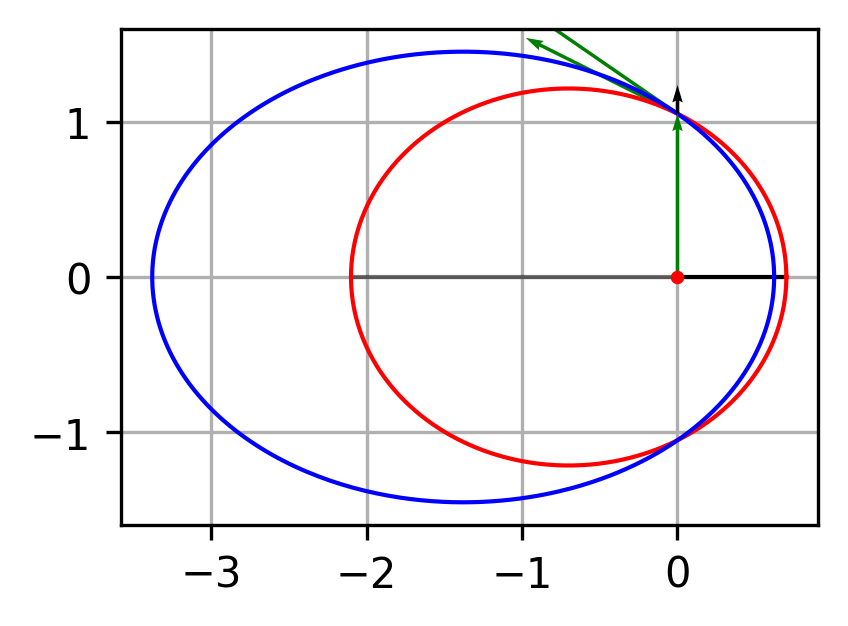

In [15]:
## change semimajor axis

a1 = 1.4
e1 = 0.5
w1 = 0

obt1 = conic(a1,e1,w1)

nu = np.deg2rad(90)
pos1 = conic(a1,e1,w1,True,nu=nu)
periapsis_og =   a1 * (1-e1) * np.array([np.cos(w1),np.sin(w1)])
apoapsis_og  = - a1 * (1+e1) * np.array([np.cos(w1),np.sin(w1)])
plt.figure(figsize=(3,3),dpi=300)
plt.plot([0,apoapsis_og [0]],[0,apoapsis_og [1]],'k-',lw=1,alpha = 0.5)
plt.plot([0,periapsis_og [0]],[0,periapsis_og [1]],'k-',lw=1,alpha = 1)
a2 = 2
r  = np.linalg.norm(pos1)
w2 = 0
print(a2,r,nu)
disc = (r * np.cos(nu))**2 - 4 * a2 * (r - a2)
if disc < 0:
    print("No orbit possible")
else: 
    e2   = (- r * np.cos(nu) + np.sqrt(disc))/(2*a2)
    e2b  = (- r * np.cos(nu) - np.sqrt(disc))/(2*a2)
    obt2 = conic(a2,e2,w2)
    v1   = obt_vel(mu,a1,e1,w1,True,nu=nu)
    v2   = obt_vel(mu,a2,e2,w2,True,nu=nu)
    dv   = v2 - v1
    plt.quiver(pos1[0],pos1[1],v1[0],v1[1],color='green',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
    plt.quiver(pos1[0],pos1[1],v2[0],v2[1],color='green',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
    plt.quiver(pos1[0],pos1[1],dv[0],dv[1],color='black',scale = 1,zorder = 3,angles='xy', scale_units='xy',width=0.005)


plt.scatter(0,0,s=5,color='r',zorder=5)
plt.plot(obt1[0],obt1[1],'r-',lw=1)
plt.plot(obt2[0],obt2[1],'b-',lw=1)
plt.quiver(0,0,pos1[0],pos1[1],color='green',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
plt.grid()
plt.gca().set_aspect("equal")
plt.show()

[[-2.00000000e+00  1.22464680e-16  6.66666667e-01  9.28203230e-01
   1.00000000e+00  9.28203230e-01  6.66666667e-01  1.22464680e-16
  -2.00000000e+00]
 [-3.46410162e+00 -2.00000000e+00 -1.15470054e+00 -5.35898385e-01
   0.00000000e+00  5.35898385e-01  1.15470054e+00  2.00000000e+00
   3.46410162e+00]]


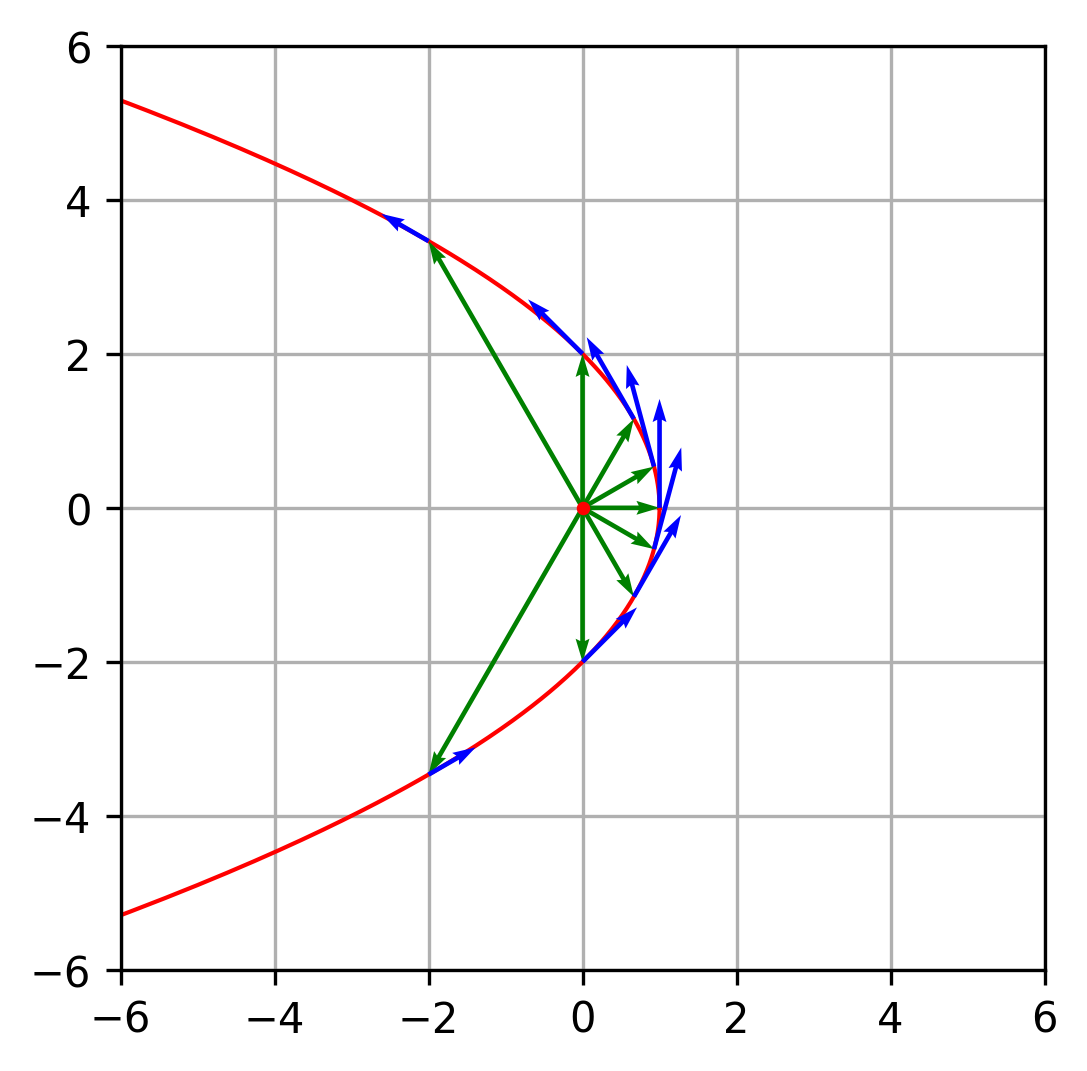

In [16]:
## PARABOLA 
rp = 1 
p  = rp * 2 
w  = np.deg2rad(0)
r  = conic(None,1,w,p=p)
v  = obt_vel(mu,None,1,w,p=p)

ta = np.deg2rad(np.arange(-120,120+30,30))
pos = conic(None,1,w,True,p=p,nu=ta)
print(pos)
vel = obt_vel(mu,None,1,w,single=True,p=p,nu=ta)
plt.figure(figsize=(4,4),dpi=300)
plt.plot(r[0],r[1],'r-',lw=1)
# plt.plot(v[0],v[1],'b-',lw=1)
for i in range(len(ta)):
    plt.quiver(0,0,pos[0,i],pos[1,i],color='green',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
    plt.quiver(pos[0,i],pos[1,i],vel[0,i],vel[1,i],color='blue',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
plt.scatter(0,0,color='r',s=5,zorder=5)
plt.gca().set_aspect('equal')
sqr = 6
plt.xlim(-sqr, sqr)
plt.ylim(-sqr, sqr)
plt.grid()
plt.show()


120.00000000000001
-1.0
[ 0.60928497 -1.67399669]


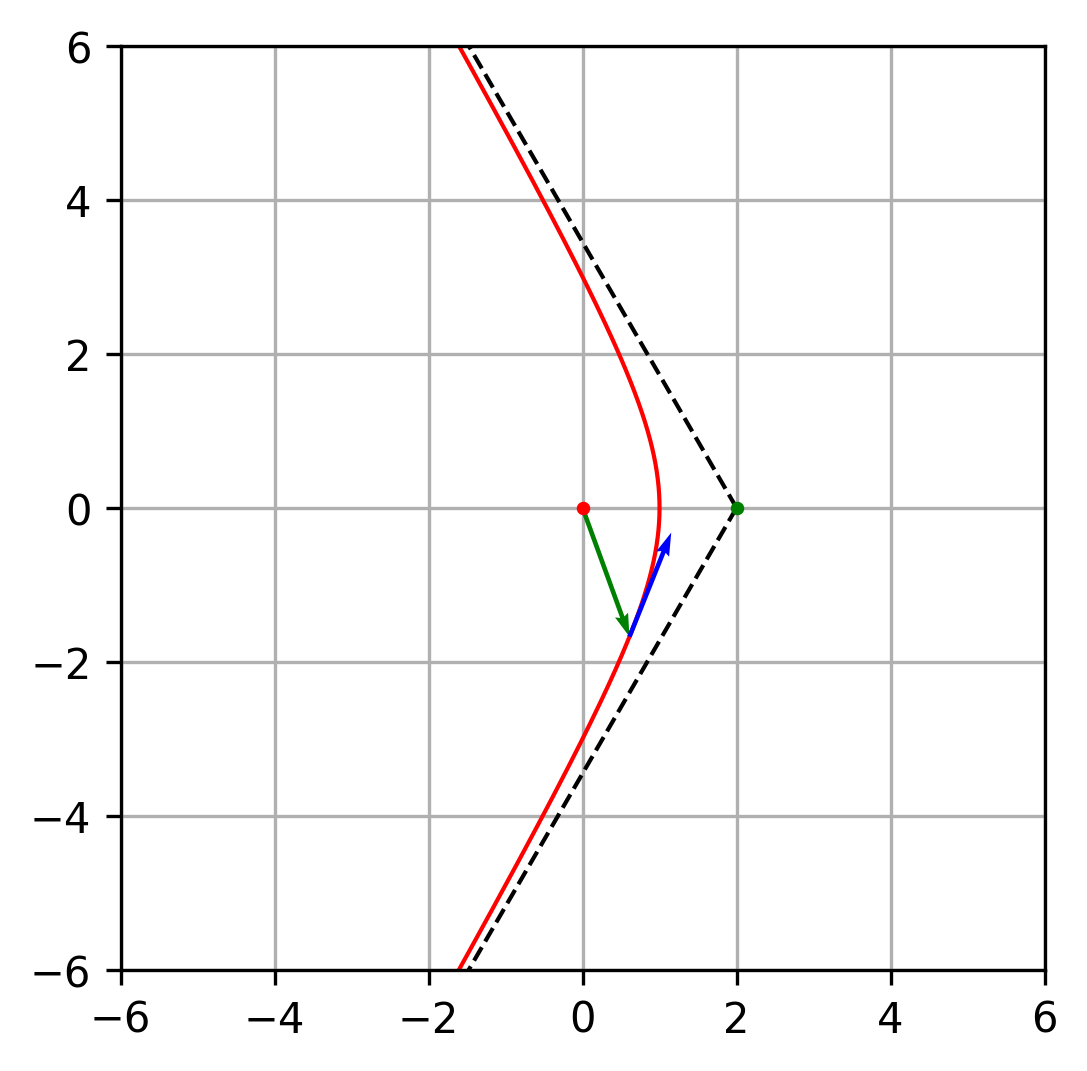

In [17]:
rp = 1
e = 2
## rp = a (1 - e )
## p  = a (e - 1) (e + 1)
a = rp / (1 - e)
p = rp * (1 + e)
w = np.deg2rad(0)

# Asymptotic true anomaly (where denominator = 0)
nu_inf = np.arccos(-1/e) 
print(np.rad2deg(nu_inf))
print(a)
# Standard hyperbola equation (focus at origin, periapsis at nu=0)
r = conic(a,e,w,nu_min=-nu_inf+0.01,nu_max=nu_inf-0.01)
v = obt_vel(mu,a,e,w,nu_min=-nu_inf,nu_max=nu_inf)


ta = np.deg2rad(-70)
pos = conic(a,e,w,single=True,nu=ta)
vel = obt_vel(mu,a,e,w,True,nu=ta)
print(pos)
plt.figure(figsize=(4,4),dpi=300)
plt.plot(r[0], r[1],'r-',lw=1)
# plt.plot(v[0],v[1],'b-',lw=1)
plt.scatter([0], [0], color='red', s=5, zorder = 5, label='Focus (Central Body)')
plt.quiver(0,0,pos[0],pos[1],color='green',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
plt.quiver(pos[0],pos[1],vel[0],vel[1],color='blue',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
# intersection point
intpt = np.array([-a*e,0])
plt.scatter(intpt[0],intpt[1], s= 5, color = 'green',zorder=6)
r = 1e3 
upper_asymp = r * np.array([np.cos(nu_inf),np.sin(nu_inf)])
lower_asymp = r * np.array([np.cos(-nu_inf),np.sin(-nu_inf)])
plt.plot([intpt[0],upper_asymp[0]],[intpt[1],upper_asymp[1]], 'k--',lw=1)
plt.plot([intpt[0],lower_asymp[0]],[intpt[1],lower_asymp[1]], 'k--',lw=1)
sqr = 6
plt.xlim(-sqr, sqr)
plt.ylim(-sqr, sqr)
plt.gca().set_aspect('equal')
# plt.xlabel('x')
# plt.ylabel('y')
# plt.title(f'Hyperbola: a={a}, e={e}, ν ∈ [{-np.degrees(nu_inf):.0f}°, {np.degrees(nu_inf):.0f}°]')
# plt.legend()
plt.grid(True)
plt.show()

3.155505344541971


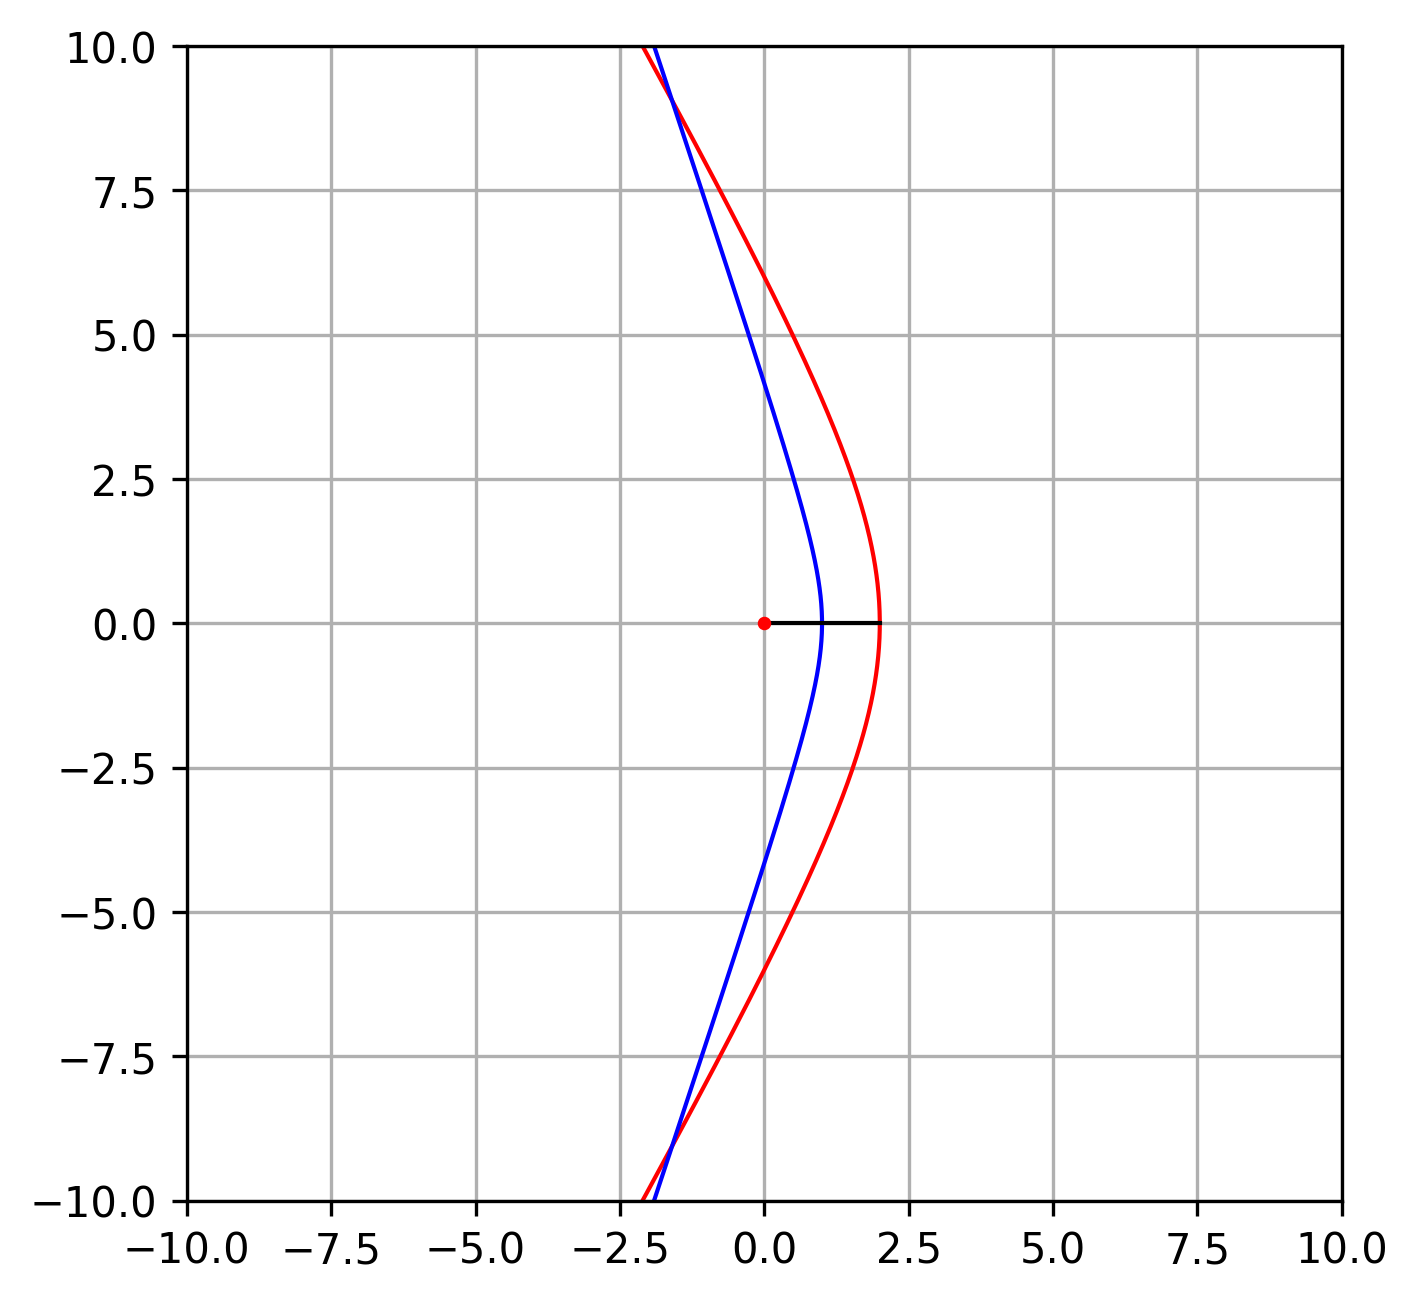

In [ ]:
rp1 = 2
e1 = 2
a1 = rp1 / (1 - e1)
p  = rp1 * (1 + a1)

nu_inf = np.acos(- 1/e1)
obt1 = conic(a1,e1,0,nu_min = - nu_inf + 0.01, nu_max = nu_inf - 0.01)

nu = np.deg2rad(-100)

rp2 = 1
e2 = (rp2 * (1 + e1 * np.cos(nu)) - rp1 * (1 + e1))/(rp1 * (1 + e1)* np.cos(nu) -  rp2 * (1 + e1 * np.cos(nu)))
print(e2)
if e2 < 0 :
    print("Orbit not possible")
    a2 = np.nan
    nu_inf = np.nan
else:
    a2 = rp2 / (1 - e2)
    nu_inf = np.acos(-1/e2)
obt2 = conic(a2,e2,0,nu_min = - nu_inf + 0.01, nu_max = nu_inf - 0.01)


plt.figure(figsize=(5,5),dpi=300)
plt.plot(obt1[0],obt1[1],'r-',lw=1)
plt.plot(obt2[0],obt2[1],'b-',lw=1)
plt.plot([0,a1*(1-e1)],[0,0],'k-',lw=1)
sqr = 10
plt.xlim(-sqr, sqr)
plt.ylim(-sqr, sqr)
plt.gca().set_aspect('equal')
plt.scatter([0], [0], color='red', s=5, zorder = 5)
plt.grid(True)
plt.show()

 
a2 = 1.17528
e2 = 0.31931


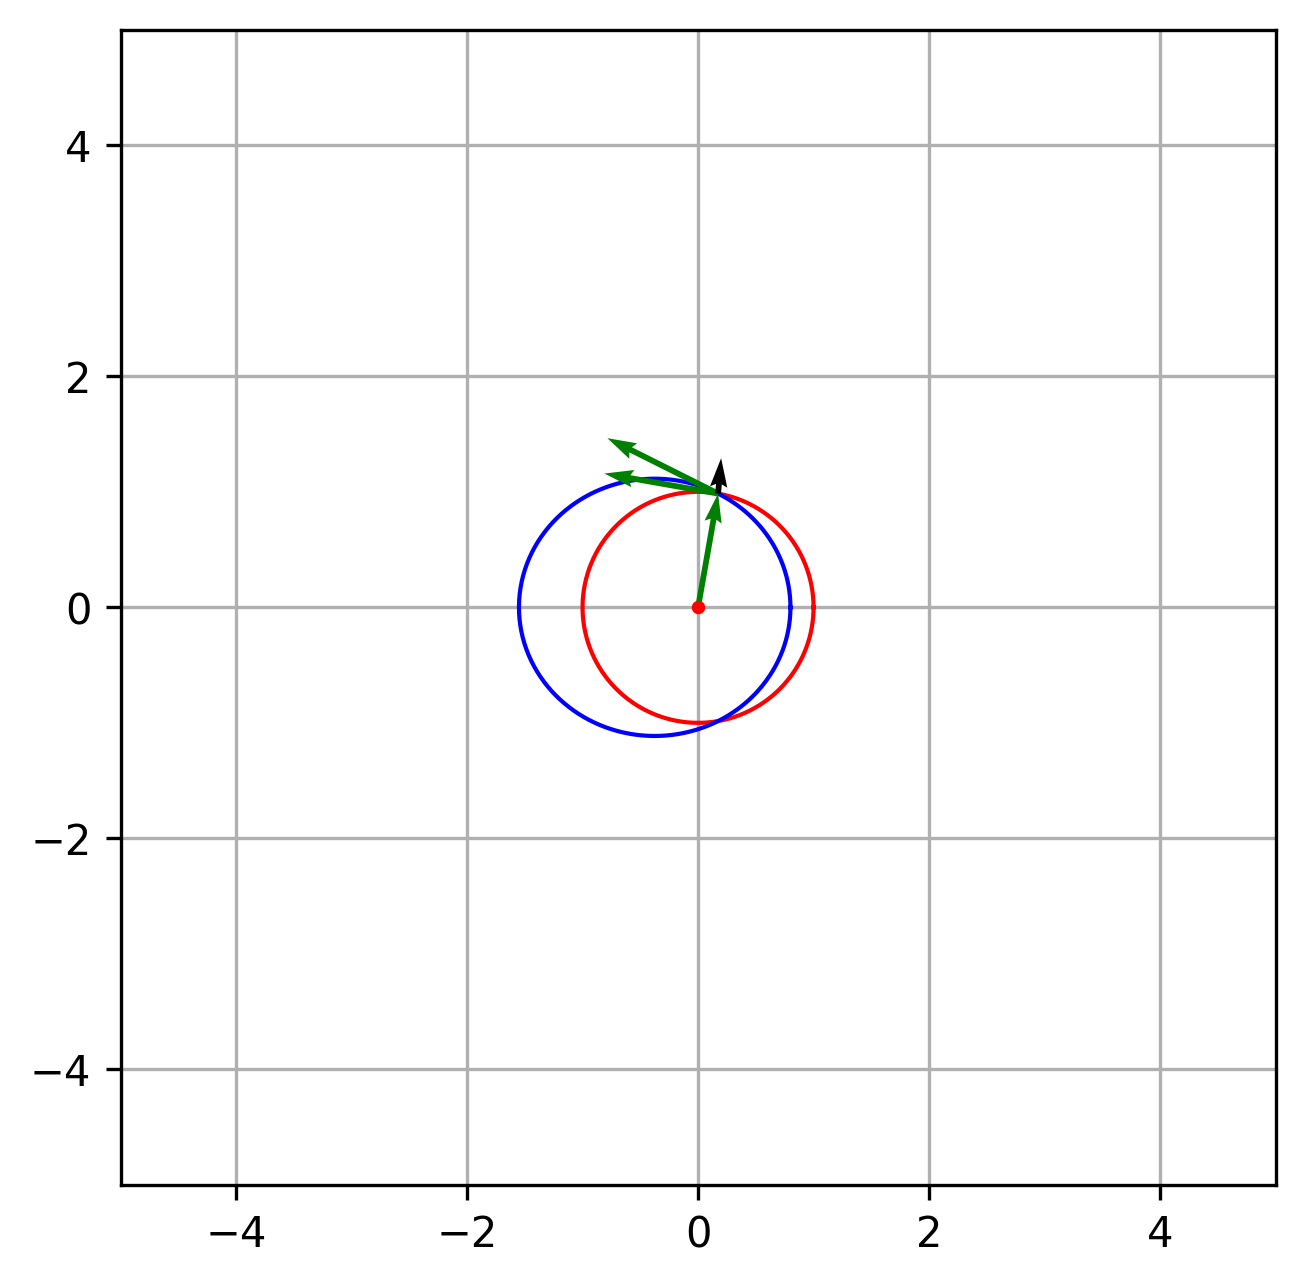

In [49]:
## CHANGE PERIAPSIS
# rp1 = 1
# ap1 = 1

a1 = 1
e1 = 0

# rp1 = 2
# e1  = 2
# a1  = rp1 / ( 1 - e1)

obt1 = conic(a1,e1)


nu = np.deg2rad(80)

rp2 = 0.8
## rmag constraints
pos1 = conic(a1,e1,single=True,nu=nu)
rmag = np.linalg.norm(pos1)
e2 = (rp2 - rmag) / (rmag * np.cos(nu) - rp2)
a2 = rp2 / (1 - e2)
v1 = obt_vel(mu,a1,e1,single=True,nu=nu)
print(f"nu_inf = {np.rad2deg(np.acos(-1/e2)):.5f}" if e2 > 1 else " ")
print(f"a2 = {a2:.5f}")
print(f"e2 = {e2:.5f}")
if e2 < 0:
    print("No orbit possible")
    obt2 = np.nan, np.nan 
    v2  = np.nan, np.nan 
else:
    obt2 = conic(a2,e2)
    v2  = obt_vel(mu,a2,e2,single=True,nu=nu)
dv = v2 - v1 

plt.figure(figsize=(5,5),dpi=300)

plt.plot(obt1[0],obt1[1],'r-',lw=1)
plt.plot(obt2[0],obt2[1],'b-',lw=1)
plt.quiver(0,0,pos1[0],pos1[1],color='green',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
plt.quiver(pos1[0],pos1[1],v1[0],v1[1],color='green',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
plt.quiver(pos1[0],pos1[1],v2[0],v2[1],color='green',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
plt.quiver(pos1[0],pos1[1],dv[0],dv[1],color='black',scale = 1,zorder = 3,angles='xy', scale_units='xy',width=0.005)
sqr = 5
plt.xlim(-sqr, sqr)
plt.ylim(-sqr, sqr)

plt.gca().set_aspect('equal')
plt.scatter([0], [0], color='red', s=5, zorder = 5)
plt.grid(True)
plt.show()

 
a2 = 71.00000
e2 = 0.98592


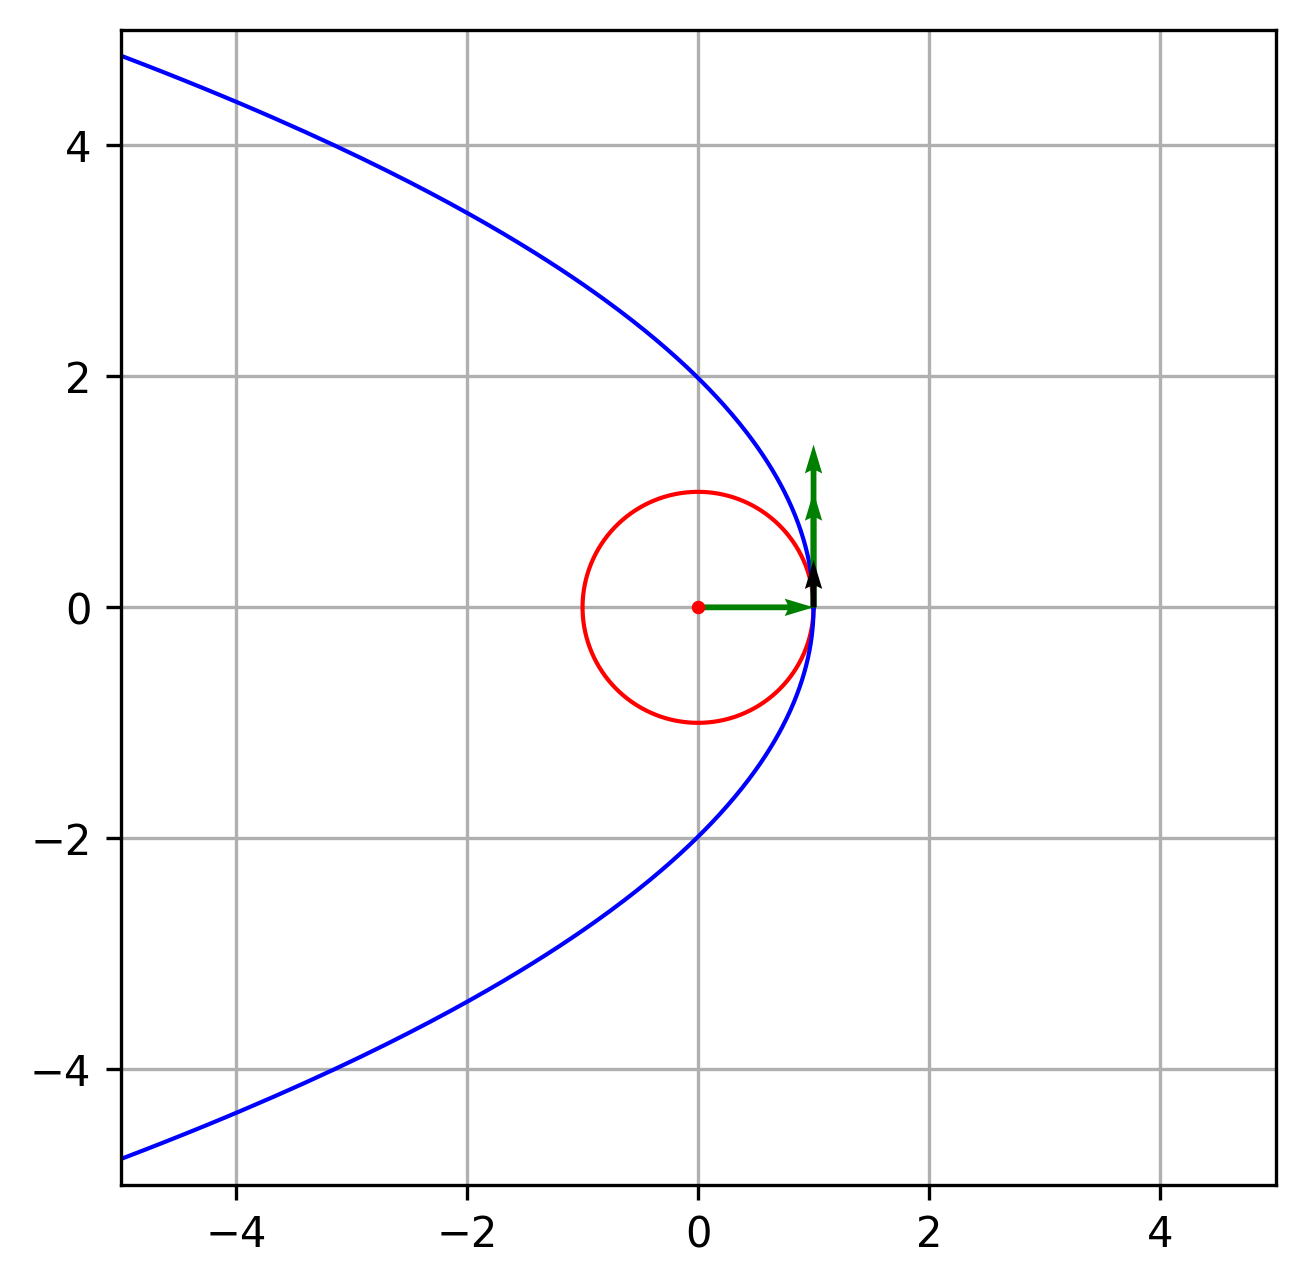

In [41]:
## CHANGE APOAPSIS
rp1 = 1 
ap1 = 1

a1 = (rp1 + ap1) / 2
e1 = (ap1 - rp1) / (rp1 + ap1)

# rp1 = 2
# e1  = 2
# a1  = rp1 / ( 1 - e1)

obt1 = conic(a1,e1)


nu = np.deg2rad(0)

ap2 = 135 + 6
## rmag constraints
pos1 = conic(a1,e1,single=True,nu=nu)
rmag = np.linalg.norm(conic(a1,e1,single=True,nu=nu))
e2 = (ap2 - rmag) / (rmag * np.cos(nu) + ap2)
print(np.rad2deg(np.acos(-1/e2)) if e2 > 1 else " ")
a2 = ap2 / (1 + e2)
v1 = obt_vel(mu,a1,e1,single=True,nu=nu)
print(f"a2 = {a2:.5f}")
print(f"e2 = {e2:.5f}")
if e2 < 0 or e2 > 1:
    print("No orbit possible")
    obt2 = np.nan, np.nan 
    v2  = np.nan, np.nan 
else:
    obt2 = conic(a2,e2)
    v2  = obt_vel(mu,a2,e2,single=True,nu=nu)
dv = v2 - v1 

plt.figure(figsize=(5,5),dpi=300)

plt.plot(obt1[0],obt1[1],'r-',lw=1)
plt.plot(obt2[0],obt2[1],'b-',lw=1)

plt.quiver(0,0,pos1[0],pos1[1],color='green',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
plt.quiver(pos1[0],pos1[1],v1[0],v1[1],color='green',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
plt.quiver(pos1[0],pos1[1],v2[0],v2[1],color='green',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
plt.quiver(pos1[0],pos1[1],dv[0],dv[1],color='black',scale = 1,zorder = 3,angles='xy', scale_units='xy',width=0.005)

sqr = 5
plt.xlim(-sqr, sqr)
plt.ylim(-sqr, sqr)

plt.gca().set_aspect('equal')
plt.scatter([0], [0], color='red', s=5, zorder = 5)
plt.grid(True)
plt.show()

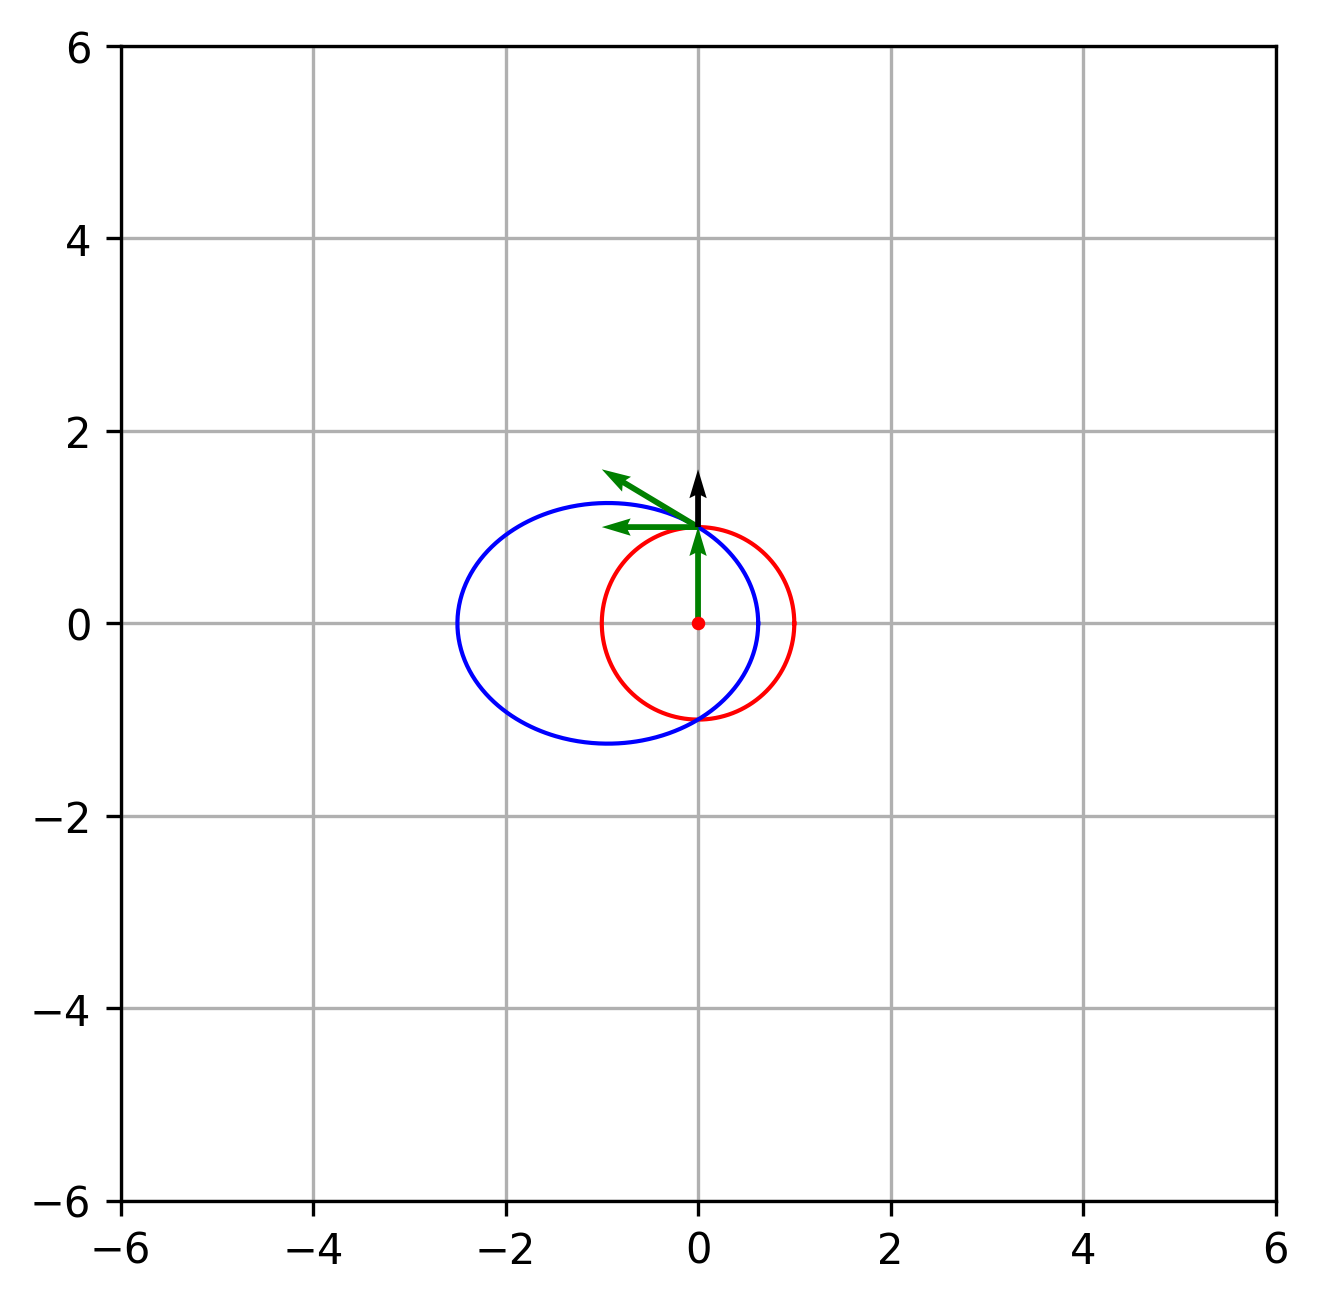

In [40]:
## CHANGE ECCENTRICITY
rp1 = 1
ap1 = 1

a1 = (rp1 + ap1) / 2
e1 = (ap1 - rp1) / (rp1 + ap1)

# rp1 = 2
# e1  = 2
# a1  = rp1 / ( 1 - e1)

obt1 = conic(a1,e1)


nu = np.deg2rad(90)

## rmag constraints
pos1 = conic(a1,e1,single=True,nu=nu)
rmag = np.linalg.norm(conic(a1,e1,single=True,nu=nu))
e2 = 0.6
a2 = rmag * (1 + e2 * np.cos(nu))/ ( 1 - e2**2)
v1 = obt_vel(mu,a1,e1,single=True,nu=nu)
if e2 < 0:
    print("No orbit possible")
    obt2 = np.nan, np.nan 
    v2  = np.nan, np.nan 
else:
    obt2 = conic(a2,e2)
    v2  = obt_vel(mu,a2,e2,single=True,nu=nu)
dv = v2 - v1 

plt.figure(figsize=(5,5),dpi=300)

plt.plot(obt1[0],obt1[1],'r-',lw=1)
plt.plot(obt2[0],obt2[1],'b-',lw=1)

plt.quiver(0,0,pos1[0],pos1[1],color='green',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
plt.quiver(pos1[0],pos1[1],v1[0],v1[1],color='green',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
plt.quiver(pos1[0],pos1[1],v2[0],v2[1],color='green',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
plt.quiver(pos1[0],pos1[1],dv[0],dv[1],color='black',scale = 1,zorder = 3,angles='xy', scale_units='xy',width=0.005)

sqr = 6
plt.xlim(-sqr, sqr)
plt.ylim(-sqr, sqr)

plt.gca().set_aspect('equal')
plt.scatter([0], [0], color='red', s=5, zorder = 5)
plt.grid(True)
plt.show()

rmag = 1.00000
e2   = 1.00933


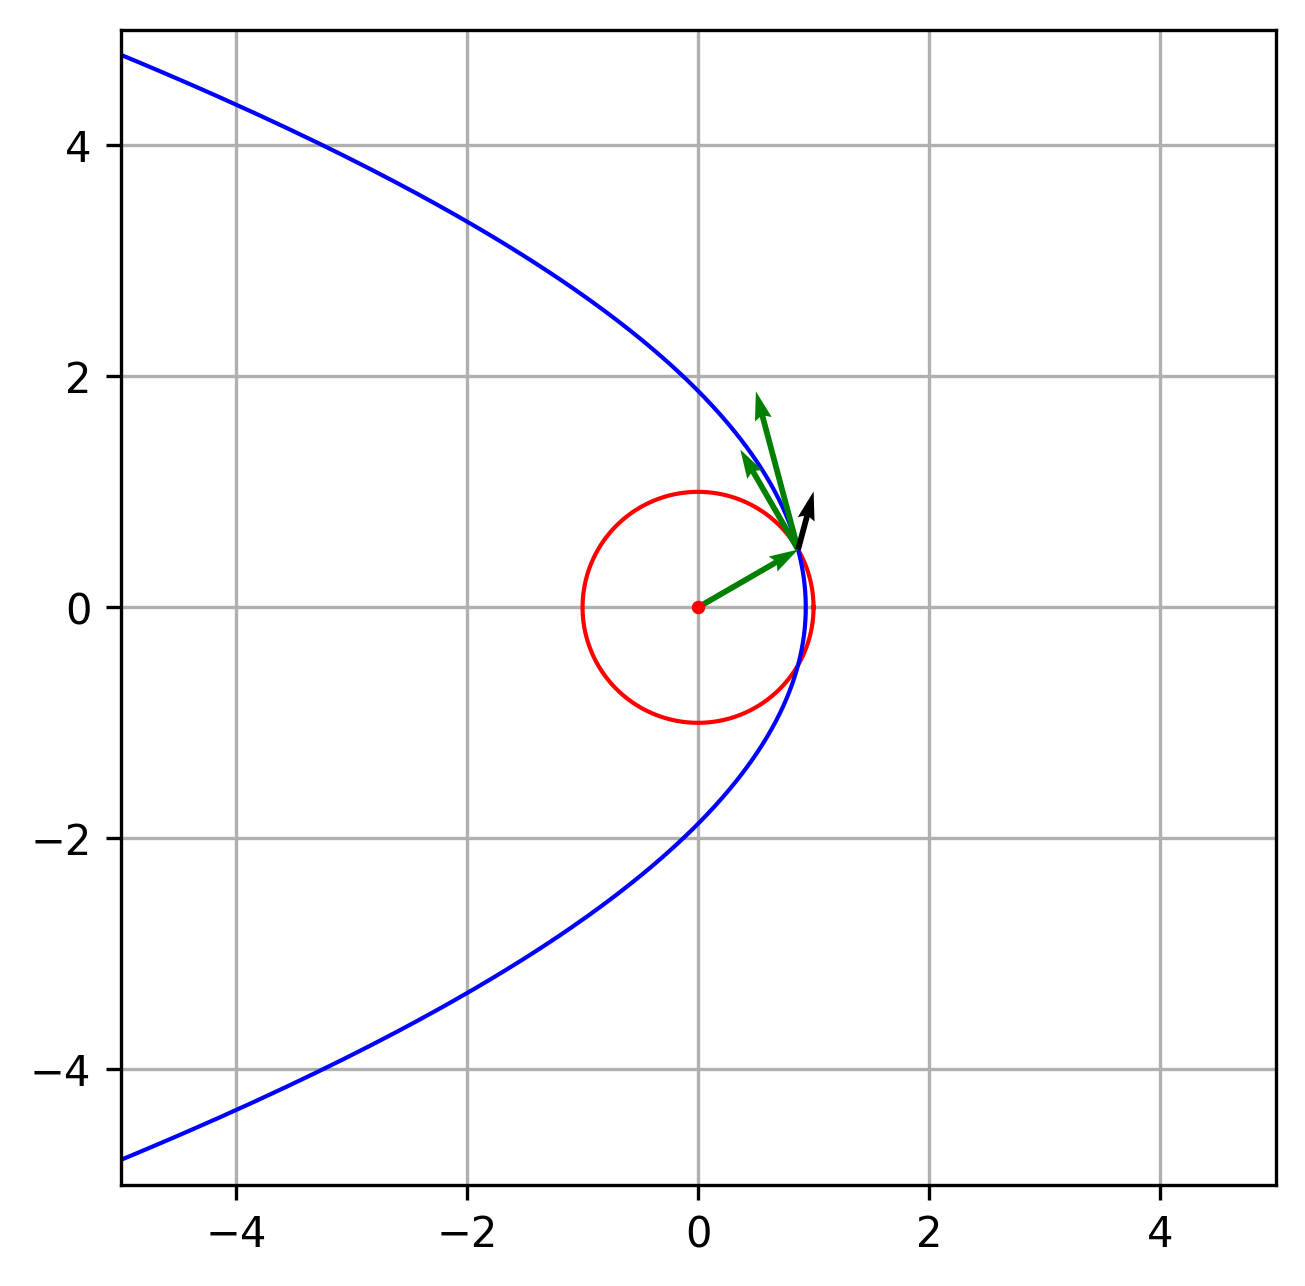

In [39]:
## CHANGE SEMIMAJORAXIS
## has problems, check later
rp1 = 1
ap1 = 1

a1 = (rp1 + ap1) / 2
e1 = (ap1 - rp1) / (rp1 + ap1)

# rp1 = 2
# e1  = 2
# a1  = rp1 / ( 1 - e1)

obt1 = conic(a1,e1)

nu = np.deg2rad(30)
pos1 = conic(a1,e1,single=True,nu=nu)
v1 = obt_vel(mu,a1,e1,single=True,nu=nu)
## rmag constraints
rmag = np.linalg.norm(conic(a1,e1,single=True,nu=nu))
print(f"rmag = {rmag:.5f}")
a2 = -100
e2 = np.nan
discrim = (rmag * np.cos(nu))**2 - 4 * a2 * (rmag - a2)
if discrim < 0:
    print("No orbit possible")
    obt2 = np.nan, np.nan 
    v2   = np.nan, np.nan
else:
    if a2 > 0:
        e2 = (- rmag * np.cos(nu) + np.sqrt(discrim))/(2*a2)
    else:
        e2 = (- rmag * np.cos(nu) - np.sqrt(discrim))/(2*a2)
    print(f"e2   = {e2:.5f}")
    if e2 < 0:
        print("No orbit possible, invalid eccentricity")
        obt2 = np.nan, np.nan 
        v2   = np.nan, np.nan
    else:
        obt2 = conic(a2,e2)
        v2  = obt_vel(mu,a2,e2,single=True,nu=nu)
dv = v2 - v1 

plt.figure(figsize=(5,5),dpi=300)

plt.plot(obt1[0],obt1[1],'r-',lw=1)
plt.plot(obt2[0],obt2[1],'b-',lw=1)

plt.quiver(0,0,pos1[0],pos1[1],color='green',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
plt.quiver(pos1[0],pos1[1],v1[0],v1[1],color='green',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
plt.quiver(pos1[0],pos1[1],v2[0],v2[1],color='green',scale = 1,zorder = 2,angles='xy', scale_units='xy',width=0.005)
plt.quiver(pos1[0],pos1[1],dv[0],dv[1],color='black',scale = 1,zorder = 3,angles='xy', scale_units='xy',width=0.005)

sqr = 5
plt.xlim(-sqr, sqr)
plt.ylim(-sqr, sqr)
plt.gca().set_aspect('equal')
plt.scatter([0], [0], color='red', s=5, zorder = 5)
plt.grid(True)
plt.show()